<a href="https://colab.research.google.com/github/Stepa555/social_media_mental_health_dashbord/blob/main/%D0%92%D0%BB%D0%B8%D1%8F%D0%BD%D0%B8%D0%B5_%D1%81%D0%BE%D1%86%D0%B5%D1%82%D0%B5%D0%B9_%D0%BD%D0%B0_%D0%BF%D1%81%D0%B8%D1%85%D0%B8%D0%BA%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Настройка графиков

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Загрузка данных

from google.colab import files
uploaded = files.upload()

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset.csv


In [ ]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')


In [ ]:
# Первый взгляд на данные

print('Первые 5 строк:')

df.head(5)

Первые 5 строк:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
print("\n Информация о пропусках и типах данных:")
df.info()


 Информация о пропусках и типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5

In [ ]:
print("\n Базовые статистики:")
df.describe()


 Базовые статистики:


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
print("\n Уникальные значения в текстовых колонках:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


 Уникальные значения в текстовых колонках:

gender:
gender
male      615
female    585
Name: count, dtype: int64

platform_usage:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

social_interaction_level:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


In [ ]:
# Базовые KPI для дашборда
print("="*50)
print("КЛЮЧЕВЫЕ МЕТРИКИ")
print("="*50)

print(f"Всего респондентов: {len(df)}")
print(f"Средний возраст: {df['age'].mean():.1f} лет")
print(f"Доля с депрессией: {df['depression_label'].mean()*100:.1f}%")
print(f"Среднее время в соцсетях: {df['daily_social_media_hours'].mean():.1f} ч/день")
print(f"Средний уровень стресса (1-10): {df['stress_level'].mean():.1f}")
print(f"Средний уровень тревоги (1-10): {df['anxiety_level'].mean():.1f}")

#  Распределение по возрасту и полу
print("\n" + "="*50)
print("РАСПРЕДЕЛЕНИЕ ПО ПОЛУ")
print("="*50)
print(df['gender'].value_counts())

# Есть ли связь между соцсетями и депрессией?
print("\n" + "="*50)
print("ВРЕМЯ В СОЦСЕТЯХ vs ДЕПРЕССИЯ")
print("="*50)
no_depression = df[df['depression_label']==0]['daily_social_media_hours'].mean()
depression = df[df['depression_label']==1]['daily_social_media_hours'].mean()
print(f"Среднее время в соцсетях (без депрессии): {no_depression:.1f} ч")
print(f"Среднее время в соцсетях (с депрессией): {depression:.1f} ч")
print(f"Разница: {depression - no_depression:.1f} ч")

КЛЮЧЕВЫЕ МЕТРИКИ
Всего респондентов: 1200
Средний возраст: 15.9 лет
Доля с депрессией: 2.6%
Среднее время в соцсетях: 4.5 ч/день
Средний уровень стресса (1-10): 5.4
Средний уровень тревоги (1-10): 5.6

РАСПРЕДЕЛЕНИЕ ПО ПОЛУ
gender
male      615
female    585
Name: count, dtype: int64

ВРЕМЯ В СОЦСЕТЯХ vs ДЕПРЕССИЯ
Среднее время в соцсетях (без депрессии): 4.5 ч
Среднее время в соцсетях (с депрессией): 6.7 ч
Разница: 2.2 ч


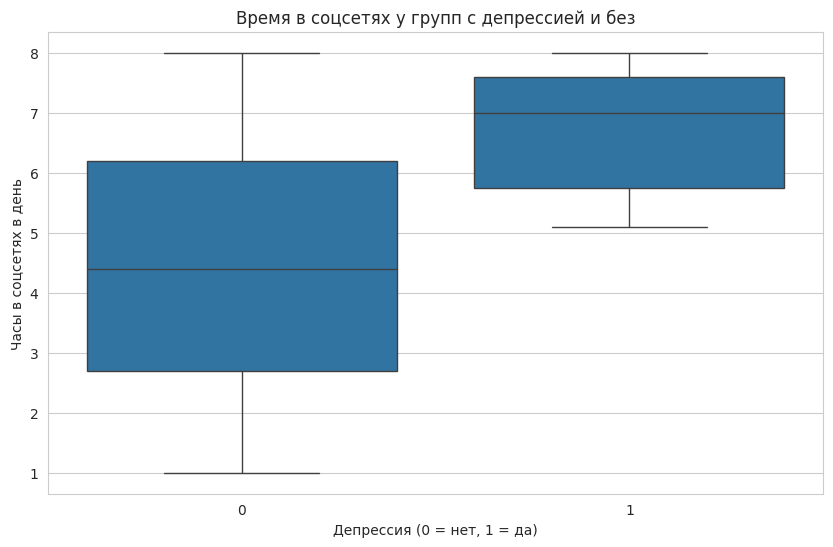

In [ ]:
# График: время в соцсетях vs уровень тревоги

plt.figure(figsize = (10,6))
sns.boxplot(x = 'depression_label', y='daily_social_media_hours', data=df)
plt.title('Время в соцсетях у групп с депрессией и без')
plt.xlabel('Депрессия (0 = нет, 1 = да)')
plt.ylabel('Часы в соцсетях в день')
plt.show()

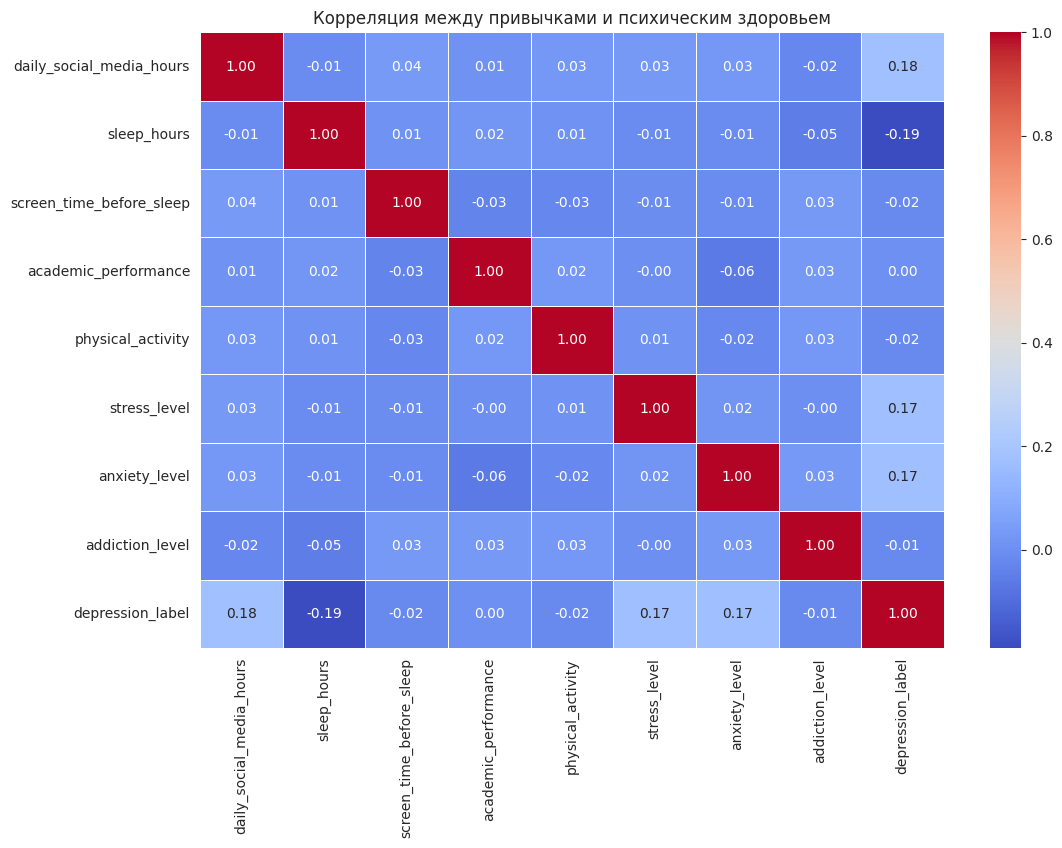

In [ ]:
# Тепловая карта корреляций

plt.figure(figsize=(12, 8))
numeric_cols = ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'stress_level',
                'anxiety_level', 'addiction_level', 'depression_label']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция между привычками и психическим здоровьем')
plt.show()

In [ ]:
# Сравнение двух групп (депрессия есть / нет)
print("\n" + "="*50)
print("СРАВНЕНИЕ ГРУПП (депрессия vs нет депрессии)")
print("="*50)

grouped = df.groupby('depression_label')[['stress_level', 'anxiety_level', 'sleep_hours',
                                           'daily_social_media_hours', 'physical_activity']].mean()
grouped


СРАВНЕНИЕ ГРУПП (депрессия vs нет депрессии)


,stress_level,anxiety_level,sleep_hours,daily_social_media_hours,physical_activity
depression_label,,,,,
0,5.365269,5.557742,6.494183,4.478785,1.016168
1,8.483871,8.612903,4.761290,6.719355,0.951613


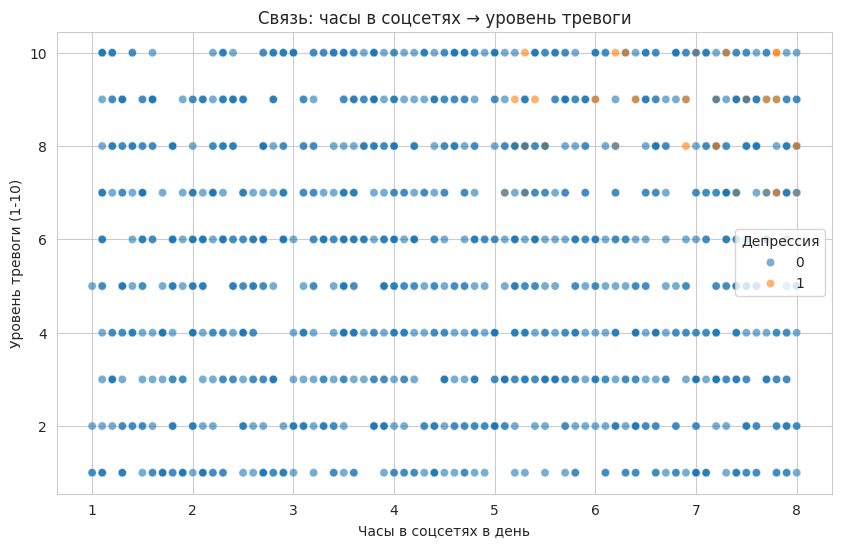

In [ ]:
# График: уровень тревоги по времени в соцсетях
plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_social_media_hours', y='anxiety_level', hue='depression_label', data=df, alpha=0.6)
plt.title('Связь: часы в соцсетях → уровень тревоги')
plt.xlabel('Часы в соцсетях в день')
plt.ylabel('Уровень тревоги (1-10)')
plt.legend(title='Депрессия')
plt.show()